In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from functools import reduce
import numpy as np
import pandas as pd
import re
import gc
import datetime as _dt
import pyarrow.parquet as pq
from collections import defaultdict
from dateutil.relativedelta import relativedelta
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.metrics import precision_recall_curve, auc
from deap import base, creator, tools, algorithms
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
df = pd.read_csv('features_weekly.csv')
df.head()

,user,week_start,week_number,email_external_ratio,email_suspicious_content_ratio,email_bcc_email_ratio,email_external_email_with_attachment_ratio,email_after_hours_or_weekend_ratio,email_max_zscore_emails,email_avg_emails_per_week,...,z_http_avg_requests_per_day,z_http_upload_ratio,z_http_download_ratio,z_http_off_hours_ratio,z_http_suspicious_ratio,psycho_ocean_risk_score,ldap_zscore_departure,users_activity_not_main_pc_ratio,users_post_departure_activity,users_pre_departure_ratio
0,AAB0162,2010-01-04,1,0.222222,0.000000,0.0,0.000000,0.0,0.0,45.00,...,0.000000,0.0,0.0,0.0,0.000000,0.062937,0.27574,0.0,0.0,0.0
1,AAB0162,2010-01-11,2,0.166667,0.000000,0.0,0.011111,0.0,0.0,45.00,...,0.000000,0.0,0.0,0.0,0.000000,0.062937,0.27574,0.0,0.0,0.0
2,AAB0162,2010-01-18,3,0.229630,0.000000,0.0,0.022222,0.0,0.0,45.00,...,0.000000,0.0,0.0,0.0,0.000000,0.062937,0.27574,0.0,0.0,0.0
3,AAB0162,2010-01-25,4,0.216374,0.000000,0.0,0.023392,0.0,0.0,42.75,...,-0.342791,0.0,0.0,0.0,-0.005614,0.062937,0.27574,0.0,0.0,0.0
4,AAB0162,2010-02-01,5,0.208333,0.009259,0.0,0.023148,0.0,0.5,43.20,...,-0.628322,0.0,0.0,0.0,0.000000,0.062937,0.27574,0.0,0.0,0.0


In [3]:
df.columns

Index(['user', 'week_start', 'week_number', 'email_external_ratio',
       'email_suspicious_content_ratio', 'email_bcc_email_ratio',
       'email_external_email_with_attachment_ratio',
       'email_after_hours_or_weekend_ratio', 'email_max_zscore_emails',
       'email_avg_emails_per_week', 'email_avg_size_sent_email',
       'email_zscore_last_month', 'z_email_external_ratio',
       'z_email_suspicious_content_ratio', 'z_email_bcc_email_ratio',
       'z_email_external_email_with_attachment_ratio',
       'z_email_after_hours_or_weekend_ratio', 'z_email_avg_emails_per_week',
       'z_email_avg_size_sent_email', 'file_copy_ratio', 'file_write_ratio',
       'file_delete_ratio', 'file_copy_to_removable_ratio',
       'file_from_removable_ratio', 'file_events_per_file',
       'file_off_hours_ratio', 'file_suspicious_file_content_ratio',
       'file_open_then_copy_ratio', 'file_copy_then_delete_ratio',
       'file_max_zscore_file_activity', 'file_zscore_last_month',
       'decoy_

In [4]:
l = pd.read_csv('cert_dataset/insiders/insiders.csv')
insiders = l[l['dataset']==6.2]['user']
insiders

186    ACM2278
187    CMP2946
188    PLJ1771
189    CDE1846
190    MBG3183
Name: user, dtype: object

In [5]:
threat_weeks = pd.read_csv('cert_dataset/insiders/threat_weeks.csv')
threat_weeks.head(30)

,user,week_start
0,ACM2278,2010-08-16
1,ACM2278,2010-08-23
2,CDE1846,2011-02-21
3,CDE1846,2011-03-14
4,CDE1846,2011-03-21
5,CDE1846,2011-03-28
6,CDE1846,2011-04-04
7,CDE1846,2011-04-11
8,CDE1846,2011-04-25
9,CMP2946,2011-01-31


In [6]:
if 'is_insider' in df.columns:
    df = df.drop(columns=['is_insider'])


threat_df = pd.DataFrame(threat_weeks, columns=['user', 'week_start'])
threat_df['is_insider'] = 1


df = df.merge(threat_df, on=['user', 'week_start'], how='left')

df['is_insider'] = df['is_insider'].fillna(0).astype(int)

print(df['is_insider'].value_counts())

is_insider
0    284040
1        21
Name: count, dtype: int64


In [8]:
X = df.drop(columns=['user','is_insider','file_open_then_copy_ratio', 'file_copy_then_delete_ratio','week_start','week_number'])

s_scaler = StandardScaler()


X_scaled_s = s_scaler.fit_transform(X)

model = IsolationForest(
    n_estimators=5000,
    max_samples=150000,
    max_features=1.0,
    random_state=42,
)

model.fit(X_scaled_s)

IsolationForest(max_samples=150000, n_estimators=5000, random_state=42)

In [9]:
df['anomaly_score'] = -model.score_samples(X_scaled_s)

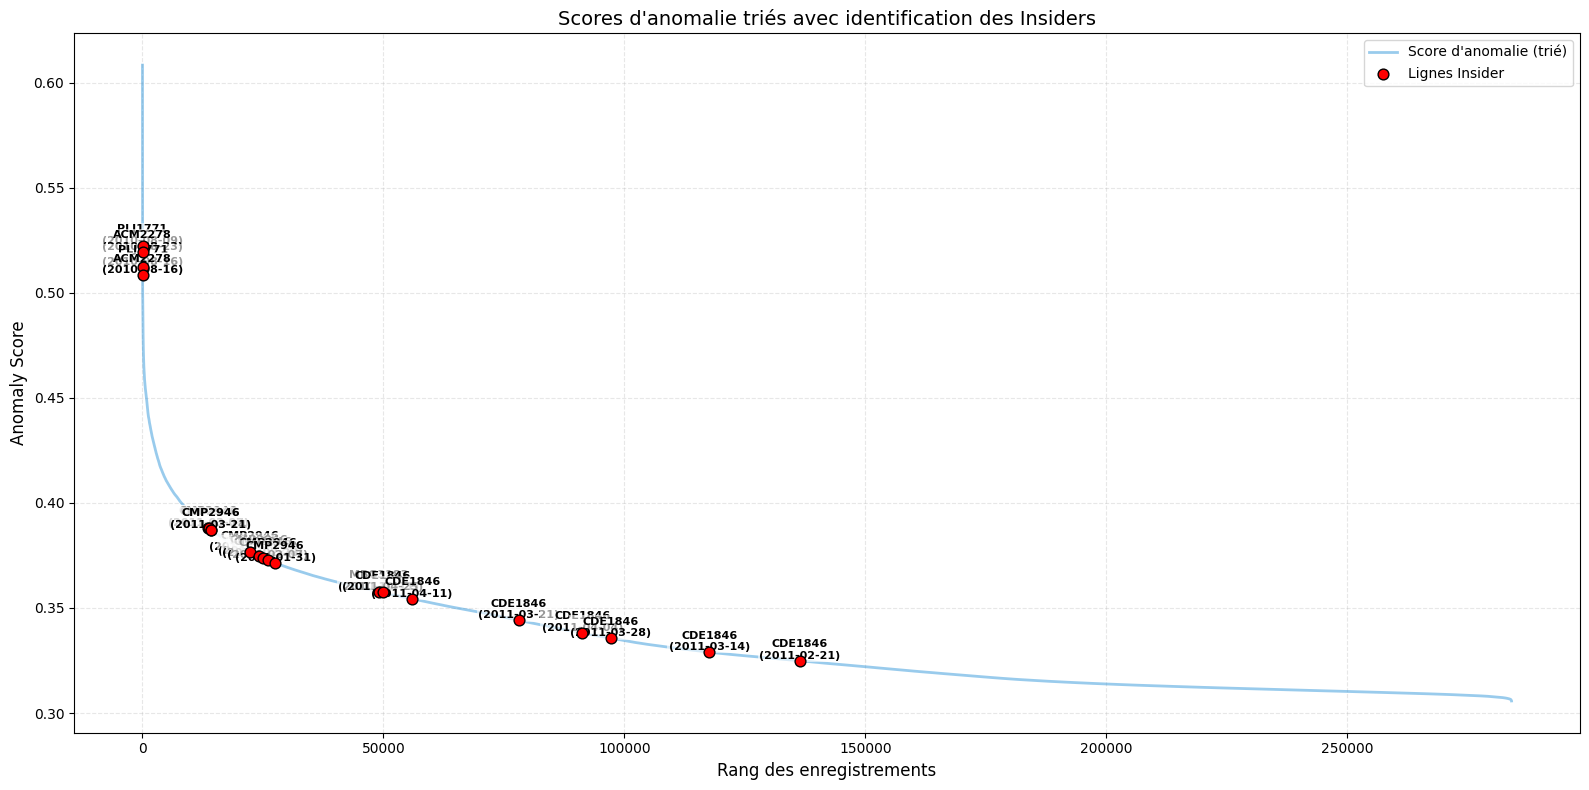

In [10]:
df_sorted = df.sort_values(by='anomaly_score', ascending=False).reset_index(drop=True)

insider_indices_sorted = df_sorted[df_sorted['is_insider'] == 1].index

plt.figure(figsize=(16, 8))

plt.plot(df_sorted.index, df_sorted['anomaly_score'], 
         label="Score d'anomalie (trié)", 
         color='#3498db', 
         alpha=0.5, 
         linewidth=2)

if len(insider_indices_sorted) > 0:
   
    plt.scatter(insider_indices_sorted, 
                df_sorted.loc[insider_indices_sorted, 'anomaly_score'], 
                color='red', 
                label='Lignes Insider', 
                s=60, 
                zorder=5,
                edgecolors='black')

   
    for idx in insider_indices_sorted:
        user = df_sorted.loc[idx, 'user']
        week = df_sorted.loc[idx, 'week_start']
        score = df_sorted.loc[idx, 'anomaly_score']
        
        
        label = f"{user}\n({week})"
        
        plt.text(idx, score, label, 
                 fontsize=8, 
                 fontweight='bold',
                 verticalalignment='bottom', 
                 horizontalalignment='center',
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

plt.title("Scores d'anomalie triés avec identification des Insiders", fontsize=14)
plt.xlabel("Rang des enregistrements", fontsize=12)
plt.ylabel("Anomaly Score", fontsize=12)
plt.legend()
plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [12]:
df.sort_values(by='anomaly_score',ascending=False)[['user','anomaly_score','is_insider']].head(30)

,user,anomaly_score,is_insider
40294,BVB1673,0.608289,0
40292,BVB1673,0.594443,0
40293,BVB1673,0.573160,0
40295,BVB1673,0.570073,0
216724,QRJ1597,0.558040,0
40296,BVB1673,0.554985,0
236841,SDH2394,0.553748,0
272219,WMM0873,0.548152,0
51606,CHM1561,0.546800,0
50940,CHB1062,0.539849,0


### Genetic Algorithm

In [24]:
df = pd.read_csv('features_weekly.csv')

X = df.drop(columns=['user','week_start','week_number'])

In [25]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [26]:
threat_weeks = pd.read_csv('cert_dataset/insiders/threat_weeks.csv')

In [27]:
if 'is_insider' in df.columns:
    df = df.drop(columns=['is_insider'])


threat_df = pd.DataFrame(threat_weeks, columns=['user', 'week_start'])
threat_df['is_insider'] = 1


df = df.merge(threat_df, on=['user', 'week_start'], how='left')

df['is_insider'] = df['is_insider'].fillna(0).astype(int)

print(df['is_insider'].value_counts())

is_insider
0    284040
1        21
Name: count, dtype: int64


In [28]:
N_FEATURES = len(X.columns)
INSIDERS =  df[df['is_insider']==1][['user','week_number']]
K = 200

In [29]:
def fitness_function(individual):

    selected = [col for col, bit in zip(X.columns, individual) if bit == 1]

    if len(selected) == 0:
        return (0.0,)
    
    X_selected = X_scaled[selected]

    clf = IsolationForest(
        n_estimators=1000,
        random_state=42,
        max_samples=150000,
        max_features=1.0,
    )

    clf.fit(X_selected)
    scores = -clf.score_samples(X_selected)
    df_scores = pd.DataFrame({'user':df['user'],'week_number':df['week_number'],'score':scores})
    df_scores = df_scores.sort_values('score',ascending=False)
    df_scores['rank'] = range(1,len(df_scores)+1)

    total_weeks = len(df_scores)
    
    insiders_ranks= df_scores.merge(
        INSIDERS,
        on=['user','week_number']
    )['rank'].values

    if len(insiders_ranks) == 0:
        return (0.0,)
    
    mean_rank = np.mean(insiders_ranks) / total_weeks

    top_k_hits = np.sum(insiders_ranks <= K) / len(INSIDERS)

    alpha = 0.6

    fitness = alpha * (1-mean_rank) + (1 - alpha) * top_k_hits

    return (fitness,)

In [30]:
creator.create('FitnessMax', base.Fitness, weights=(1.0,))
creator.create('Individual', list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

toolbox.register('attr_bool',np.random.randint,0,2)
toolbox.register('individual',tools.initRepeat,
                 creator.Individual, toolbox.attr_bool, n=N_FEATURES)
toolbox.register('population',tools.initRepeat,
                 list,toolbox.individual)
toolbox.register('evaluate',fitness_function)

toolbox.register('mate', tools.cxTwoPoint)
toolbox.register('mutate',tools.mutFlipBit,indpb=0.05)
toolbox.register('select',tools.selTournament,tournsize=3)

c:\Users\OsakaGamingMaroc\miniconda3\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
c:\Users\OsakaGamingMaroc\miniconda3\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


In [31]:
def run_ga(pop_size=70,n_gen=30):

    pop = toolbox.population(n=pop_size)
    hof = tools.HallOfFame(1)

    stats = tools.Statistics(lambda ind : ind.fitness.values)
    stats.register('max', np.max)
    stats.register('mean',np.mean)

    algorithms.eaSimple(
        pop, toolbox,
        cxpb=0.7, mutpb=0.2,
        ngen=n_gen,
        stats=stats,
        halloffame=hof,
        verbose=True
    )

    return hof[0]

best = run_ga()

best_features = [col for col, bit in zip(X.columns, best) if bit == 1]
print(f"Features sélectionnées ({len(best_features)}) :", best_features)
print("Fitness :", best.fitness.values[0])

gen	nevals	max     	mean    
0  	70    	0.611805	0.557806
1  	42    	0.618216	0.584752
2  	56    	0.62138 	0.599086
3  	46    	0.6231  	0.607136
4  	64    	0.625857	0.60932 
5  	50    	0.628016	0.614362
6  	55    	0.633831	0.619923
7  	50    	0.637011	0.624947
8  	59    	0.637601	0.62492 
9  	57    	0.639159	0.627813
10 	52    	0.639159	0.63238 
11 	45    	0.64024 	0.63294 
12 	57    	0.644597	0.636008
13 	40    	0.644659	0.637153
14 	58    	0.644597	0.639303
15 	55    	0.648817	0.639998
16 	50    	0.648817	0.641386
17 	49    	0.648817	0.643547
18 	52    	0.650207	0.644681
19 	52    	0.650207	0.646224
20 	49    	0.650935	0.646243
21 	50    	0.652518	0.647329
22 	56    	0.652518	0.647873
23 	58    	0.653533	0.648605
24 	52    	0.653533	0.648739
25 	54    	0.654014	0.650912
26 	60    	0.654405	0.650693
27 	51    	0.654776	0.650978
28 	50    	0.654776	0.652275
29 	55    	0.654776	0.651181
30 	53    	0.654897	0.652461
Features sélectionnées (30) : ['email_bcc_email_ratio', 'email_max_zscor

In [32]:
X_with_best_features = X_scaled[best_features]

model = IsolationForest(
    n_estimators=10000,
    max_samples=125000,
    max_features=1.0,
    random_state=42
)

model.fit(X_with_best_features)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",10000
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",125000
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [33]:
df['anomaly_score_best_features'] = -model.score_samples(X_with_best_features)

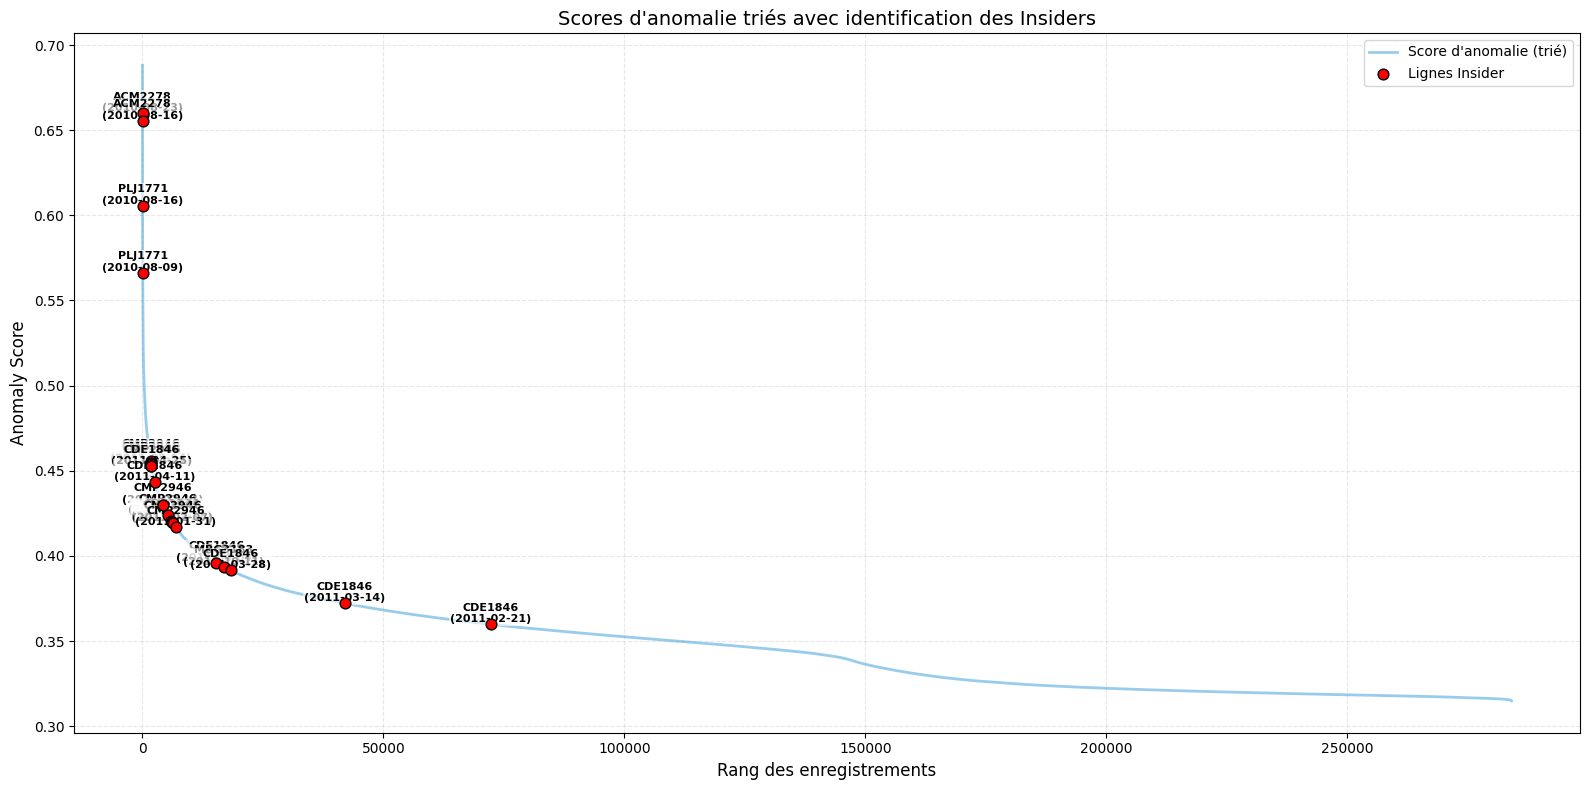

In [34]:
df_sorted = df.sort_values(by='anomaly_score_best_features', ascending=False).reset_index(drop=True)

insider_indices_sorted = df_sorted[df_sorted['is_insider'] == 1].index

plt.figure(figsize=(16, 8))

plt.plot(df_sorted.index, df_sorted['anomaly_score_best_features'], 
         label="Score d'anomalie (trié)", 
         color='#3498db', 
         alpha=0.5, 
         linewidth=2)

if len(insider_indices_sorted) > 0:
   
    plt.scatter(insider_indices_sorted, 
                df_sorted.loc[insider_indices_sorted, 'anomaly_score_best_features'], 
                color='red', 
                label='Lignes Insider', 
                s=60, 
                zorder=5,
                edgecolors='black')

   
    for idx in insider_indices_sorted:
        user = df_sorted.loc[idx, 'user']
        week = df_sorted.loc[idx, 'week_start']
        score = df_sorted.loc[idx, 'anomaly_score_best_features']
        
        
        label = f"{user}\n({week})"
        
        plt.text(idx, score, label, 
                 fontsize=8, 
                 fontweight='bold',
                 verticalalignment='bottom', 
                 horizontalalignment='center',
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

plt.title("Scores d'anomalie triés avec identification des Insiders", fontsize=14)
plt.xlabel("Rang des enregistrements", fontsize=12)
plt.ylabel("Anomaly Score", fontsize=12)
plt.legend()
plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [ ]:
df.sort_values(by='anomaly_score_best_features',ascending=False)[['user','anomaly_score_best_features','is_insider']].head(50)

,user,anomaly_score_best_features,is_insider
40292,BVB1673,0.638970,0
216724,QRJ1597,0.620622,0
40294,BVB1673,0.618284,0
40293,BVB1673,0.606335,0
4515,ACM2278,0.597854,1
4517,ACM2278,0.596195,0
4518,ACM2278,0.590548,0
4514,ACM2278,0.589646,1
211862,PLJ1771,0.587345,1
4519,ACM2278,0.586057,0


### Encoder

In [2]:
df = pd.read_csv('features_weekly.csv')

In [3]:
threat_weeks = pd.read_csv('cert_dataset/insiders/threat_weeks.csv')

if 'is_insider' in df.columns:
    df = df.drop(columns=['is_insider'])


threat_df = pd.DataFrame(threat_weeks, columns=['user', 'week_start'])
threat_df['is_insider'] = 1


df = df.merge(threat_df, on=['user', 'week_start'], how='left')

df['is_insider'] = df['is_insider'].fillna(0).astype(int)

print(df['is_insider'].value_counts())

is_insider
0    284040
1        21
Name: count, dtype: int64


In [4]:
X = df.drop(columns=['week_start','user','week_number','is_insider'])

X_train = X[df['is_insider']==0]
X_all = X.copy()

In [5]:
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_all_scaled = pd.DataFrame(scaler.transform(X_all), columns=X.columns)

In [6]:
X_tensor_train = torch.FloatTensor(X_train.values)

X_tensor_all = torch.FloatTensor(X_all_scaled.values)

dataset = TensorDataset(X_tensor_train)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [7]:
class Autoencoder(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(n_features, 48),  
            nn.ReLU(),
            nn.Linear(48, 24),          
            nn.ReLU(),
            nn.Linear(24, 12),        
            nn.ReLU(),
            nn.Linear(12, 4),           
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(4, 12),
            nn.ReLU(),
            nn.Linear(12, 24),
            nn.ReLU(),
            nn.Linear(24, 48),
            nn.ReLU(),
            nn.Linear(48, n_features), 
        )
    
    def forward(self, x):
        return self.decoder(self.encoder(x))

model = Autoencoder(n_features=X.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()

best_loss = float('inf')
best_state = None

for epoch in range(500):
    model.train()
    epoch_loss = 0
    for (batch,) in loader:
        reconstructed = model(batch)
        loss = criterion(reconstructed, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(loader)
    
    if avg_loss < best_loss:
        best_loss = avg_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch} — Loss: {avg_loss:.4f}")

model.load_state_dict(best_state)

Epoch 0 — Loss: 0.5331
Epoch 20 — Loss: 0.3339
Epoch 40 — Loss: 0.3234
Epoch 60 — Loss: 0.3189
Epoch 80 — Loss: 0.3170
Epoch 100 — Loss: 0.3143
Epoch 120 — Loss: 0.3124
Epoch 140 — Loss: 0.3105
Epoch 160 — Loss: 0.3112
Epoch 180 — Loss: 0.3098
Epoch 200 — Loss: 0.3085
Epoch 220 — Loss: 0.3075
Epoch 240 — Loss: 0.3074
Epoch 260 — Loss: 0.3068
Epoch 280 — Loss: 0.3058
Epoch 300 — Loss: 0.3064
Epoch 320 — Loss: 0.3057
Epoch 340 — Loss: 0.3051
Epoch 360 — Loss: 0.3048
Epoch 380 — Loss: 0.3051
Epoch 400 — Loss: 0.3049
Epoch 420 — Loss: 0.3064
Epoch 440 — Loss: 0.3056
Epoch 460 — Loss: 0.3053
Epoch 480 — Loss: 0.3046


<All keys matched successfully>

In [8]:
K = 200

model.eval()
with torch.no_grad():
    reconstructed = model(X_tensor_all)
    errors = torch.mean((X_tensor_all - reconstructed) ** 2, dim=1).numpy()

df_scores = pd.DataFrame({
    'user'       : df['user'],
    'week_start' : df['week_start'],
    'is_insider' : df['is_insider'],
    'score'      : errors
})

df_scores = df_scores.sort_values('score', ascending=False)
df_scores['rank'] = range(1, len(df_scores) + 1)

print("Ranking des insiders :")

df_scores_insiders = df_scores[df_scores['is_insider']==1].copy()

print(df_scores_insiders[['user', 'score', 'rank']])

print(f"\nTop-{K} hit rate : {(df_scores_insiders['rank'] <= K).sum()} / 21")

mean_rank = df_scores_insiders['rank'].mean()

print(f"Mean rank : {mean_rank:.1f} / {len(df_scores)}")

Ranking des insiders :
           user      score    rank
211862  PLJ1771  16.374683       2
4514    ACM2278  11.964841      12
4515    ACM2278  11.662584      13
211863  PLJ1771   9.296584      25
48275   CDE1846   1.422851    5078
48272   CDE1846   1.416634    5126
48277   CDE1846   1.145453    8528
176732  MBG3183   0.707128   25136
57916   CMP2946   0.681823   27027
57919   CMP2946   0.675305   27505
57917   CMP2946   0.664592   28372
57918   CMP2946   0.656993   29052
57913   CMP2946   0.567962   38357
57914   CMP2946   0.561560   39130
57915   CMP2946   0.530456   43184
48274   CDE1846   0.522272   44293
57912   CMP2946   0.501682   47337
57911   CMP2946   0.499682   47642
48273   CDE1846   0.418044   62289
48271   CDE1846   0.384823   69989
48268   CDE1846   0.186277  139325

Top-200 hit rate : 4 / 21
Mean rank : 32734.4 / 284061
